In [34]:
!pip install yfinance pandas numpy matplotlib plotly duckdb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wizar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import pickle
from sklearn.preprocessing import RobustScaler

RAW_DIR       = "./data/raw"
PROCESSED_DIR = "./data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Working directory : {os.getcwd()}")
print(f"Raw folder exists : {os.path.exists(RAW_DIR)}")
print(f"Files available:")
for f in sorted(os.listdir(RAW_DIR)):
    size = os.path.getsize(os.path.join(RAW_DIR, f)) / 1024
    print(f"  {f:20s}  {size:7.1f} KB")

Working directory : s:\ML models\algo2
Raw folder exists : True
Files available:
  btc_1d.csv              143.5 KB
  btc_1h.csv             1482.8 KB
  btc_4h.csv              382.9 KB
  eth_1d.csv              165.6 KB
  eth_1h.csv             1721.6 KB
  eth_4h.csv              443.8 KB


In [53]:
def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(RAW_DIR, filename)
    df = pd.read_csv(path, index_col="timestamp", parse_dates=True)
    print(f"Loaded '{filename}': {len(df)} rows")
    return df

btc_1h = load_csv("btc_1h.csv")
eth_1h = load_csv("eth_1h.csv")
btc_4h = load_csv("btc_4h.csv")
eth_4h = load_csv("eth_4h.csv")
btc_1d = load_csv("btc_1d.csv")
eth_1d = load_csv("eth_1d.csv")

print("\nAll data loaded successfully.")

Loaded 'btc_1h.csv': 17453 rows
Loaded 'eth_1h.csv': 17450 rows
Loaded 'btc_4h.csv': 4366 rows
Loaded 'eth_4h.csv': 4366 rows
Loaded 'btc_1d.csv': 1827 rows
Loaded 'eth_1d.csv': 1827 rows

All data loaded successfully.


In [54]:
# Always work with RETURNS not raw prices.
# Raw prices are non-stationary (drift over time).
# Returns are stationary — much better for ML models.

def add_returns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["return_1"]  = df["close"].pct_change(1)
    df["return_3"]  = df["close"].pct_change(3)
    df["return_6"]  = df["close"].pct_change(6)
    df["return_12"] = df["close"].pct_change(12)
    df["return_24"] = df["close"].pct_change(24)
    return df

btc_1h = add_returns(btc_1h)
eth_1h = add_returns(eth_1h)

print("Returns added.")
print(btc_1h[["close","return_1","return_6","return_24"]].tail(5))

Returns added.
                                  close  return_1  return_6  return_24
timestamp                                                             
2026-03-18 08:00:00+00:00  74030.093750  0.001922 -0.004331  -0.001859
2026-03-18 09:00:00+00:00  74154.804688  0.001685 -0.004912   0.002763
2026-03-18 10:00:00+00:00  73936.054688 -0.002950 -0.003368   0.002927
2026-03-18 11:00:00+00:00  72931.210938 -0.013591 -0.013785  -0.015213
2026-03-18 12:00:00+00:00  72781.820312 -0.002048 -0.015971  -0.012851


In [55]:
def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Exponential Moving Averages
    df["ema_9"]  = df["close"].ewm(span=9,  adjust=False).mean()
    df["ema_21"] = df["close"].ewm(span=21, adjust=False).mean()
    df["ema_50"] = df["close"].ewm(span=50, adjust=False).mean()

    # EMA crossovers — positive = bullish, negative = bearish
    df["ema_9_21_cross"]  = df["ema_9"]  - df["ema_21"]
    df["ema_21_50_cross"] = df["ema_21"] - df["ema_50"]

    # Price distance from EMAs (normalized)
    df["price_vs_ema21"] = (df["close"] - df["ema_21"]) / df["ema_21"]
    df["price_vs_ema50"] = (df["close"] - df["ema_50"]) / df["ema_50"]

    # MACD
    ema_12 = df["close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"]        = ema_12 - ema_26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    return df

btc_1h = add_trend_features(btc_1h)
eth_1h = add_trend_features(eth_1h)

print("Trend features added.")
print(btc_1h[["close","ema_21","macd","macd_hist"]].tail(5))

Trend features added.
                                  close        ema_21        macd   macd_hist
timestamp                                                                    
2026-03-18 08:00:00+00:00  74030.093750  74147.705213  -15.935077  -57.201549
2026-03-18 09:00:00+00:00  74154.804688  74148.350620  -11.729817  -42.397031
2026-03-18 10:00:00+00:00  73936.054688  74129.050990  -25.751567  -45.135025
2026-03-18 11:00:00+00:00  72931.210938  74020.156439 -116.602279 -108.788589
2026-03-18 12:00:00+00:00  72781.820312  73907.580428 -198.370012 -152.445058


In [56]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, adjust=False).mean()
    avg_loss = loss.ewm(com=period - 1, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def add_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["rsi_7"]  = compute_rsi(df["close"], 7)
    df["rsi_14"] = compute_rsi(df["close"], 14)
    df["rsi_21"] = compute_rsi(df["close"], 21)

    # Are fast and slow RSI agreeing?
    df["rsi_divergence"] = df["rsi_7"] - df["rsi_21"]

    # Rate of Change
    df["roc_6"]  = df["close"].pct_change(6)  * 100
    df["roc_12"] = df["close"].pct_change(12) * 100
    df["roc_24"] = df["close"].pct_change(24) * 100

    return df

btc_1h = add_momentum_features(btc_1h)
eth_1h = add_momentum_features(eth_1h)

print("Momentum features added.")
print(btc_1h[["close","rsi_7","rsi_14","rsi_21"]].tail(5))

Momentum features added.
                                  close      rsi_7     rsi_14     rsi_21
timestamp                                                               
2026-03-18 08:00:00+00:00  74030.093750  45.784647  48.302042  50.429599
2026-03-18 09:00:00+00:00  74154.804688  51.228438  50.457800  51.717904
2026-03-18 10:00:00+00:00  73936.054688  42.496301  46.773503  49.355446
2026-03-18 11:00:00+00:00  72931.210938  22.208720  34.361673  40.444525
2026-03-18 12:00:00+00:00  72781.820312  20.510381  32.961281  39.335884


In [57]:
def add_volatility_features(df: pd.DataFrame, window: int = 20) -> pd.DataFrame:
    df = df.copy()

    # Bollinger Bands
    df["bb_mid"]   = df["close"].rolling(window).mean()
    bb_std         = df["close"].rolling(window).std()
    df["bb_upper"] = df["bb_mid"] + 2 * bb_std
    df["bb_lower"] = df["bb_mid"] - 2 * bb_std
    df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["bb_mid"]

    # Where is price within the bands? 0 = lower band, 1 = upper band
    bb_range          = (df["bb_upper"] - df["bb_lower"]).replace(0, np.nan)
    df["bb_position"] = (df["close"] - df["bb_lower"]) / bb_range

    # ATR (Average True Range)
    high_low   = df["high"] - df["low"]
    high_close = (df["high"] - df["close"].shift(1)).abs()
    low_close  = (df["low"]  - df["close"].shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df["atr_14"] = true_range.ewm(span=14, adjust=False).mean()

    # ATR as % of price — normalized so it's comparable over time
    df["atr_pct"] = df["atr_14"] / df["close"]

    return df

btc_1h = add_volatility_features(btc_1h)
eth_1h = add_volatility_features(eth_1h)

print("Volatility features added.")
print(btc_1h[["close","bb_position","bb_width","atr_pct"]].tail(5))

Volatility features added.
                                  close  bb_position  bb_width   atr_pct
timestamp                                                               
2026-03-18 08:00:00+00:00  74030.093750     0.352008  0.016584  0.004970
2026-03-18 09:00:00+00:00  74154.804688     0.427110  0.015111  0.004723
2026-03-18 10:00:00+00:00  73936.054688     0.256774  0.015410  0.004844
2026-03-18 11:00:00+00:00  72931.210938    -0.265339  0.021707  0.006283
2026-03-18 12:00:00+00:00  72781.820312    -0.147100  0.027396  0.005917


In [58]:
#8
def add_volume_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["vol_ma_6"]  = df["volume"].rolling(6).mean()
    df["vol_ma_24"] = df["volume"].rolling(24).mean()
    df["vol_ratio"] = df["volume"] / df["vol_ma_24"].replace(0, np.nan)

    # Fill vol_ratio NaN at start with 1.0 (neutral — no data yet)
    df["vol_ratio"] = df["vol_ratio"].fillna(1.0)

    df["obv"] = (np.sign(df["close"].diff()) * df["volume"]).fillna(0).cumsum()

    obv_mean = df["obv"].rolling(24).mean()
    obv_std  = df["obv"].rolling(24).std()
    df["obv_zscore"] = np.where(
        obv_std > 1e-8,
        (df["obv"] - obv_mean) / obv_std,
        0.0
    )
    # Fill early NaN from rolling window warmup
    df["obv_zscore"] = pd.Series(df["obv_zscore"], index=df.index).fillna(0.0)

    # ── vol_price_corr removed — 95% NaN makes it useless ──
    # Rolling correlation on hourly crypto data is too sparse to be reliable

    return df

btc_1h = add_volume_features(btc_1h)
eth_1h = add_volume_features(eth_1h)

print("Volume features added.")
print(f"NaN in vol features: {btc_1h[['vol_ratio','obv_zscore']].isnull().sum().sum()}")

Volume features added.
NaN in vol features: 0


In [59]:
#9
# ── Simpler approach: reindex + ffill directly ──
# No merge_asof needed — just align indexes and forward fill

def strip_tz(df):
    df = df.copy()
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df.index = pd.to_datetime(df.index)
    return df

# Strip tz from 1h data once — used in all merges
btc_1h = strip_tz(btc_1h)
eth_1h = strip_tz(eth_1h)

# ── Compute BTC 4h features ──
btc_4h_c = strip_tz(btc_4h)
btc_4h_c["ema_21_4h"]    = btc_4h_c["close"].ewm(span=21, adjust=False).mean()
btc_4h_c["ema_50_4h"]    = btc_4h_c["close"].ewm(span=50, adjust=False).mean()
btc_4h_c["rsi_14_4h"]    = compute_rsi(btc_4h_c["close"], 14)
btc_4h_c["trend_4h"]     = (btc_4h_c["ema_21_4h"] > btc_4h_c["ema_50_4h"]).astype(int)
btc_4h_c["macd_hist_4h"] = (
    btc_4h_c["close"].ewm(span=12, adjust=False).mean() -
    btc_4h_c["close"].ewm(span=26, adjust=False).mean()
)

# ── Compute ETH 4h features ──
eth_4h_c = strip_tz(eth_4h)
eth_4h_c["ema_21_4h"]    = eth_4h_c["close"].ewm(span=21, adjust=False).mean()
eth_4h_c["ema_50_4h"]    = eth_4h_c["close"].ewm(span=50, adjust=False).mean()
eth_4h_c["rsi_14_4h"]    = compute_rsi(eth_4h_c["close"], 14)
eth_4h_c["trend_4h"]     = (eth_4h_c["ema_21_4h"] > eth_4h_c["ema_50_4h"]).astype(int)
eth_4h_c["macd_hist_4h"] = (
    eth_4h_c["close"].ewm(span=12, adjust=False).mean() -
    eth_4h_c["close"].ewm(span=26, adjust=False).mean()
)

cols_4h = ["ema_21_4h","rsi_14_4h","trend_4h","macd_hist_4h"]

# ── Verify columns exist before merging ──
print("BTC 4h cols check:", all(c in btc_4h_c.columns for c in cols_4h))
print("ETH 4h cols check:", all(c in eth_4h_c.columns for c in cols_4h))

# ── Merge: reindex to 1h index then forward fill ──
for col in cols_4h:
    btc_1h[col] = btc_4h_c[col].reindex(btc_1h.index, method="ffill")
    eth_1h[col] = eth_4h_c[col].reindex(eth_1h.index, method="ffill")

    # bfill handles the very start where no prior 4h candle exists yet
    btc_1h[col] = btc_1h[col].bfill()
    eth_1h[col] = eth_1h[col].bfill()

print(f"\nBTC rows : {len(btc_1h)}  ← should be ~17,000")
print(f"ETH rows : {len(eth_1h)}")
print(f"NaN in 4h cols (BTC): {btc_1h[cols_4h].isnull().sum().sum()}")
print(btc_1h[["close","trend_4h","rsi_14_4h","macd_hist_4h"]].tail(3))

BTC 4h cols check: True
ETH 4h cols check: True

BTC rows : 17453  ← should be ~17,000
ETH rows : 17450
NaN in 4h cols (BTC): 0
                            close  trend_4h  rsi_14_4h  macd_hist_4h
timestamp                                                           
2026-03-18 10:00:00  73936.054688         1  49.673580    701.912652
2026-03-18 11:00:00  72931.210938         1  49.673580    701.912652
2026-03-18 12:00:00  72781.820312         1  48.502102    574.717085


In [60]:
#10
# ── Compute BTC daily features ──
btc_1d_c = strip_tz(btc_1d)
btc_1d_c.index = btc_1d_c.index.normalize()  # floor to midnight
btc_1d_c["ema_50_1d"]     = btc_1d_c["close"].ewm(span=50,  adjust=False).mean()
btc_1d_c["ema_200_1d"]    = btc_1d_c["close"].ewm(span=200, adjust=False).mean()
btc_1d_c["ema_200_1d"]    = btc_1d_c["ema_200_1d"].fillna(btc_1d_c["ema_50_1d"])
btc_1d_c["bull_regime"]   = (
    (btc_1d_c["close"]      > btc_1d_c["ema_50_1d"]) &
    (btc_1d_c["ema_50_1d"]  > btc_1d_c["ema_200_1d"])
).astype(int)
btc_1d_c["rsi_14_1d"]     = compute_rsi(btc_1d_c["close"], 14)
btc_1d_c["daily_atr_pct"] = (btc_1d_c["high"] - btc_1d_c["low"]) / btc_1d_c["close"]

# ── Compute ETH daily features ──
eth_1d_c = strip_tz(eth_1d)
eth_1d_c.index = eth_1d_c.index.normalize()
eth_1d_c["ema_50_1d"]     = eth_1d_c["close"].ewm(span=50,  adjust=False).mean()
eth_1d_c["ema_200_1d"]    = eth_1d_c["close"].ewm(span=200, adjust=False).mean()
eth_1d_c["ema_200_1d"]    = eth_1d_c["ema_200_1d"].fillna(eth_1d_c["ema_50_1d"])
eth_1d_c["bull_regime"]   = (
    (eth_1d_c["close"]      > eth_1d_c["ema_50_1d"]) &
    (eth_1d_c["ema_50_1d"]  > eth_1d_c["ema_200_1d"])
).astype(int)
eth_1d_c["rsi_14_1d"]     = compute_rsi(eth_1d_c["close"], 14)
eth_1d_c["daily_atr_pct"] = (eth_1d_c["high"] - eth_1d_c["low"]) / eth_1d_c["close"]

cols_1d = ["bull_regime","rsi_14_1d","daily_atr_pct","ema_200_1d"]

# ── Merge: floor 1h index to date, reindex, forward fill ──
btc_1h_dates = btc_1h.index.normalize()
eth_1h_dates = eth_1h.index.normalize()

for col in cols_1d:
    btc_1h[col] = btc_1d_c[col].reindex(btc_1h_dates).values
    eth_1h[col] = eth_1d_c[col].reindex(eth_1h_dates).values

    btc_1h[col] = btc_1h[col].ffill().bfill()
    eth_1h[col] = eth_1h[col].ffill().bfill()

print(f"BTC rows : {len(btc_1h)}  ← should be ~17,000")
print(f"ETH rows : {len(eth_1h)}")
print(f"NaN in daily cols (BTC): {btc_1h[cols_1d].isnull().sum().sum()}")
print(btc_1h[["close","bull_regime","rsi_14_1d","daily_atr_pct"]].tail(3))

BTC rows : 17453  ← should be ~17,000
ETH rows : 17450
NaN in daily cols (BTC): 0
                            close  bull_regime  rsi_14_1d  daily_atr_pct
timestamp                                                               
2026-03-18 10:00:00  73936.054688            0  55.601045       0.025383
2026-03-18 11:00:00  72931.210938            0  55.601045       0.025383
2026-03-18 12:00:00  72781.820312            0  55.601045       0.025383


In [63]:
#11
PREDICTION_HORIZON = 6
THRESHOLD          = 0.005

def add_target(df: pd.DataFrame,
               horizon   : int   = PREDICTION_HORIZON,
               threshold : float = THRESHOLD) -> pd.DataFrame:
    df = df.copy()

    df["future_return"] = df["close"].pct_change(horizon).shift(-horizon)

    # 3-class target
    # SELL (0) → price falls more than -0.5% in 6h
    # HOLD (1) → price stays within ±0.5%
    # BUY  (2) → price rises more than +0.5% in 6h
    conditions = [
        df["future_return"] >  threshold,
        df["future_return"] < -threshold,
    ]
    choices      = [2, 0]
    df["target"] = np.select(conditions, choices, default=1)

    counts = df["target"].value_counts().sort_index()
    total  = len(df.dropna(subset=["target"]))
    labels = {0: "SELL", 1: "HOLD", 2: "BUY"}
    print("  Class distribution:")
    for cls, label in labels.items():
        n   = counts.get(cls, 0)
        pct = n / total * 100
        print(f"    {label} ({cls}): {n:,}  ({pct:.1f}%)")

    return df

print("BTC:")
btc_1h = add_target(btc_1h)
print("\nETH:")
eth_1h = add_target(eth_1h)

BTC:
  Class distribution:
    SELL (0): 4,478  (25.7%)
    HOLD (1): 8,176  (46.8%)
    BUY (2): 4,799  (27.5%)

ETH:
  Class distribution:
    SELL (0): 5,632  (32.3%)
    HOLD (1): 5,931  (34.0%)
    BUY (2): 5,887  (33.7%)


In [66]:
# Remove vol_price_corr in-place — works even if kernel ignores reassignment
if "vol_price_corr" in feature_cols:
    feature_cols.remove("vol_price_corr")
    print(f"Removed vol_price_corr. New length: {len(feature_cols)}")
else:
    print("Already removed.")

print(f"vol_price_corr in list: {'vol_price_corr' in feature_cols}")

# Also drop the column from both dataframes if it exists
for df_name, df in [("btc_1h", btc_1h), ("eth_1h", eth_1h)]:
    if "vol_price_corr" in df.columns:
        df.drop(columns=["vol_price_corr"], inplace=True)
        print(f"Dropped vol_price_corr from {df_name}")

# Now finalize
def finalize_features(df: pd.DataFrame, name: str) -> pd.DataFrame:
    initial        = len(df)
    nan_summary    = df[feature_cols].isnull().sum()
    remaining_nans = nan_summary[nan_summary > 0]
    if len(remaining_nans) > 0:
        print(f"  {name} — NaN columns:")
        print(remaining_nans.to_string())
    else:
        print(f"  {name} — no NaN in any feature column")
    df = df.dropna(subset=feature_cols + ["target"])
    print(f"  Dropped {initial - len(df)} rows | {len(df)} usable rows remain")
    return df

print("\nBTC:")
btc_final = finalize_features(btc_1h, "BTC")
print("\nETH:")
eth_final = finalize_features(eth_1h, "ETH")
print(f"\nTotal features : {len(feature_cols)}")

Removed vol_price_corr. New length: 31
vol_price_corr in list: False

BTC:
  BTC — NaN columns:
return_1           1
return_3           3
return_6           6
return_12         12
return_24         24
rsi_7              1
rsi_14             1
rsi_21             1
rsi_divergence     1
roc_6              6
roc_12            12
roc_24            24
bb_width          19
bb_position       19
  Dropped 24 rows | 17429 usable rows remain

ETH:
  ETH — NaN columns:
return_1           1
return_3           3
return_6           6
return_12         12
return_24         24
rsi_7              1
rsi_14             1
rsi_21             1
rsi_divergence     1
roc_6              6
roc_12            12
roc_24            24
bb_width          19
bb_position       19
  Dropped 24 rows | 17426 usable rows remain

Total features : 31


In [68]:
def time_split(df: pd.DataFrame, feature_cols: list):
    n         = len(df)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train = df.iloc[:train_end]
    val   = df.iloc[train_end:val_end]
    test  = df.iloc[val_end:]

    print(f"  Train : {len(train):,} rows | {train.index[0].date()} → {train.index[-1].date()}")
    print(f"  Val   : {len(val):,}   rows | {val.index[0].date()} → {val.index[-1].date()}")
    print(f"  Test  : {len(test):,}   rows | {test.index[0].date()} → {test.index[-1].date()}")

    return (
        train[feature_cols], train["target"],
        val[feature_cols],   val["target"],
        test[feature_cols],  test["target"]
    )

print("BTC split:")
X_train_btc, y_train_btc, X_val_btc, y_val_btc, X_test_btc, y_test_btc = time_split(btc_final, feature_cols)
print("\nETH split:")
X_train_eth, y_train_eth, X_val_eth, y_val_eth, X_test_eth, y_test_eth = time_split(eth_final, feature_cols)

BTC split:
  Train : 12,200 rows | 2024-03-21 → 2025-08-11
  Val   : 2,614   rows | 2025-08-11 → 2025-11-28
  Test  : 2,615   rows | 2025-11-28 → 2026-03-18

ETH split:
  Train : 12,198 rows | 2024-03-21 → 2025-08-11
  Val   : 2,614   rows | 2025-08-11 → 2025-11-28
  Test  : 2,614   rows | 2025-11-28 → 2026-03-18


In [70]:
# RobustScaler handles crypto outliers better than StandardScaler
# IMPORTANT: fit on train only — never on val or test

scaler_btc = RobustScaler()
X_train_btc_scaled = scaler_btc.fit_transform(X_train_btc)
X_val_btc_scaled   = scaler_btc.transform(X_val_btc)
X_test_btc_scaled  = scaler_btc.transform(X_test_btc)

scaler_eth = RobustScaler()
X_train_eth_scaled = scaler_eth.fit_transform(X_train_eth)
X_val_eth_scaled   = scaler_eth.transform(X_val_eth)
X_test_eth_scaled  = scaler_eth.transform(X_test_eth)

print("Scaling complete.")
print(f"BTC train shape : {X_train_btc_scaled.shape}")
print(f"ETH train shape : {X_train_eth_scaled.shape}")

Scaling complete.
BTC train shape : (12200, 31)
ETH train shape : (12198, 31)


In [71]:
def save_splits(X_tr, y_tr, X_v, y_v, X_te, y_te, scaler, name, feature_cols):
    out = {
        "X_train"     : X_tr,
        "y_train"     : y_tr,
        "X_val"       : X_v,
        "y_val"       : y_v,
        "X_test"      : X_te,
        "y_test"      : y_te,
        "scaler"      : scaler,
        "feature_cols": feature_cols
    }
    path = os.path.join(PROCESSED_DIR, f"{name}_features.pkl")
    with open(path, "wb") as f:
        pickle.dump(out, f)
    size = os.path.getsize(path) / 1024
    print(f"Saved : {path}  ({size:.1f} KB)")

save_splits(X_train_btc_scaled, y_train_btc,
            X_val_btc_scaled,   y_val_btc,
            X_test_btc_scaled,  y_test_btc,
            scaler_btc, "btc", feature_cols)

save_splits(X_train_eth_scaled, y_train_eth,
            X_val_eth_scaled,   y_val_eth,
            X_test_eth_scaled,  y_test_eth,
            scaler_eth, "eth", feature_cols)

print("\nPhase 2 complete. Ready for Phase 3.")

Saved : ./data/processed\btc_features.pkl  (4632.7 KB)
Saved : ./data/processed\eth_features.pkl  (4631.9 KB)

Phase 2 complete. Ready for Phase 3.


C:\Users\wizar\AppData\Local\Temp\ipykernel_15760\1354443899.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df_plot = btc_final.last("90D")


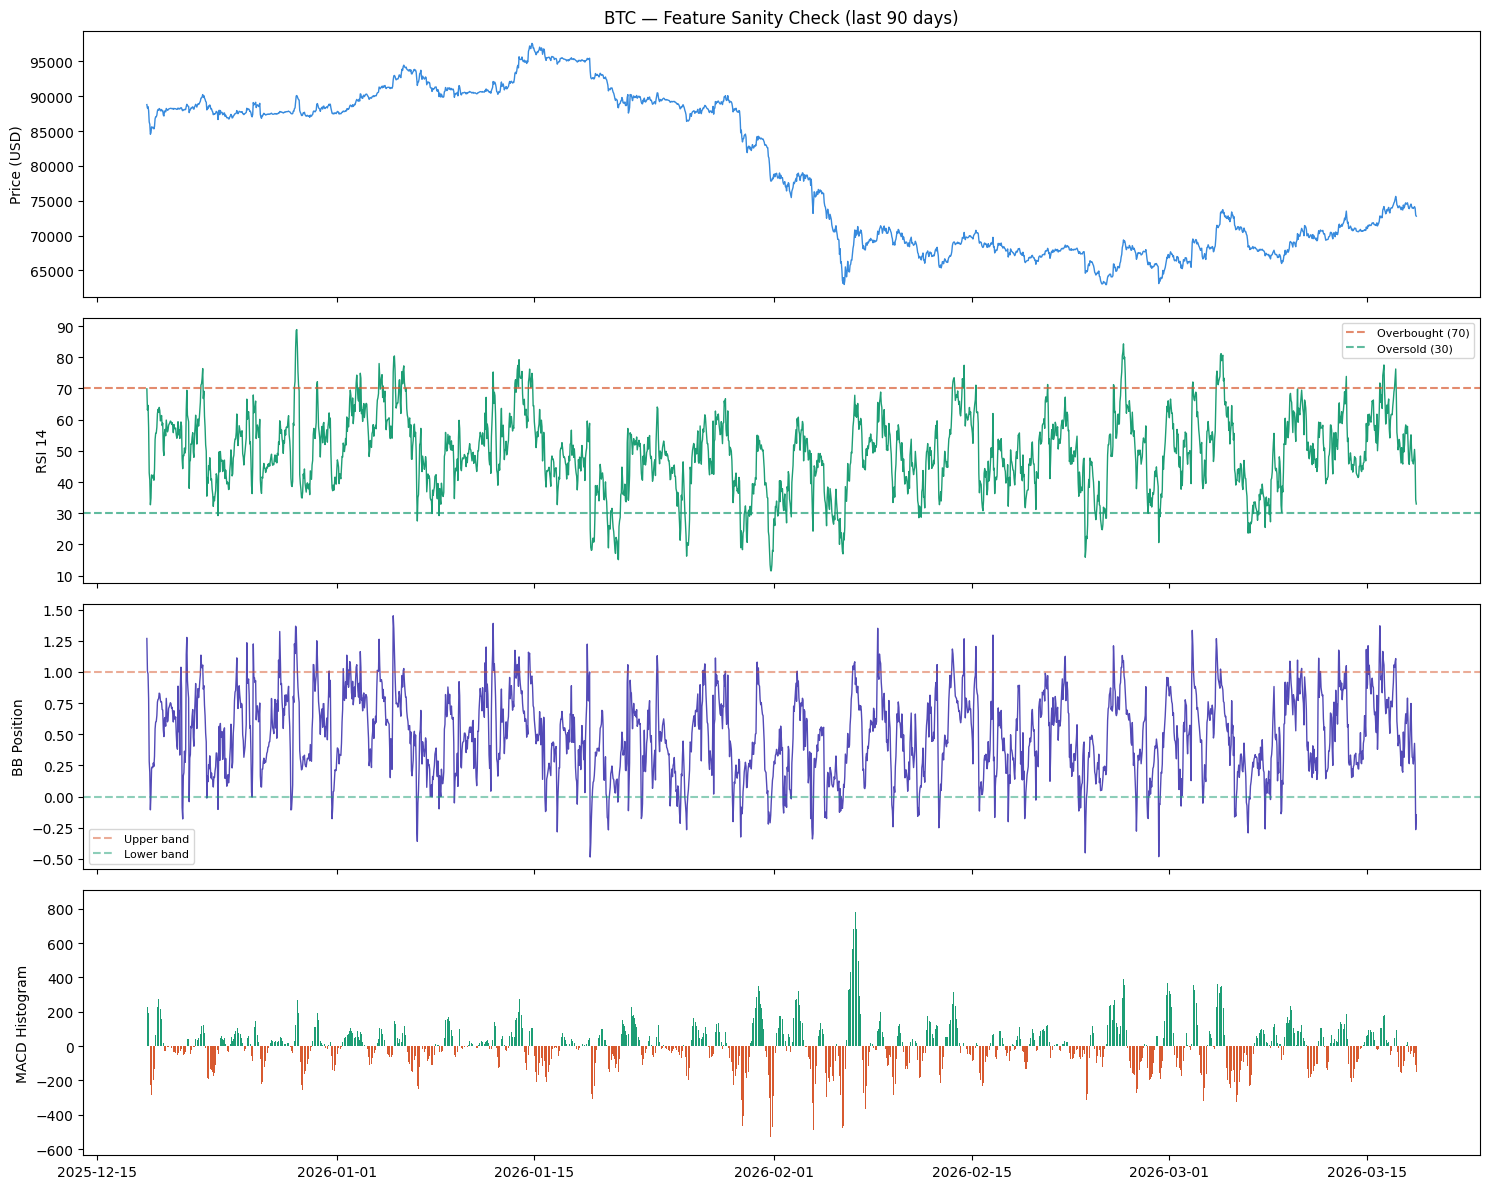

Chart saved to: ./data/processed\feature_check.png


In [72]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
df_plot = btc_final.last("90D")

axes[0].plot(df_plot.index, df_plot["close"], color="#378ADD", linewidth=1)
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("BTC — Feature Sanity Check (last 90 days)")

axes[1].plot(df_plot.index, df_plot["rsi_14"], color="#1D9E75", linewidth=1)
axes[1].axhline(70, color="#D85A30", linestyle="--", alpha=0.7, label="Overbought (70)")
axes[1].axhline(30, color="#1D9E75", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[1].set_ylabel("RSI 14")
axes[1].legend(fontsize=8)

axes[2].plot(df_plot.index, df_plot["bb_position"], color="#534AB7", linewidth=1)
axes[2].axhline(1.0, color="#D85A30", linestyle="--", alpha=0.5, label="Upper band")
axes[2].axhline(0.0, color="#1D9E75", linestyle="--", alpha=0.5, label="Lower band")
axes[2].set_ylabel("BB Position")
axes[2].legend(fontsize=8)

axes[3].bar(df_plot.index, df_plot["macd_hist"],
            color=["#1D9E75" if v > 0 else "#D85A30" for v in df_plot["macd_hist"]],
            width=0.03)
axes[3].set_ylabel("MACD Histogram")

plt.tight_layout()
chart_path = os.path.join(PROCESSED_DIR, "feature_check.png")
plt.savefig(chart_path, dpi=120)
plt.show()
print(f"Chart saved to: {chart_path}")

C:\Users\wizar\AppData\Local\Temp\ipykernel_15760\1193150382.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df_plot_eth = eth_final.last("90D")


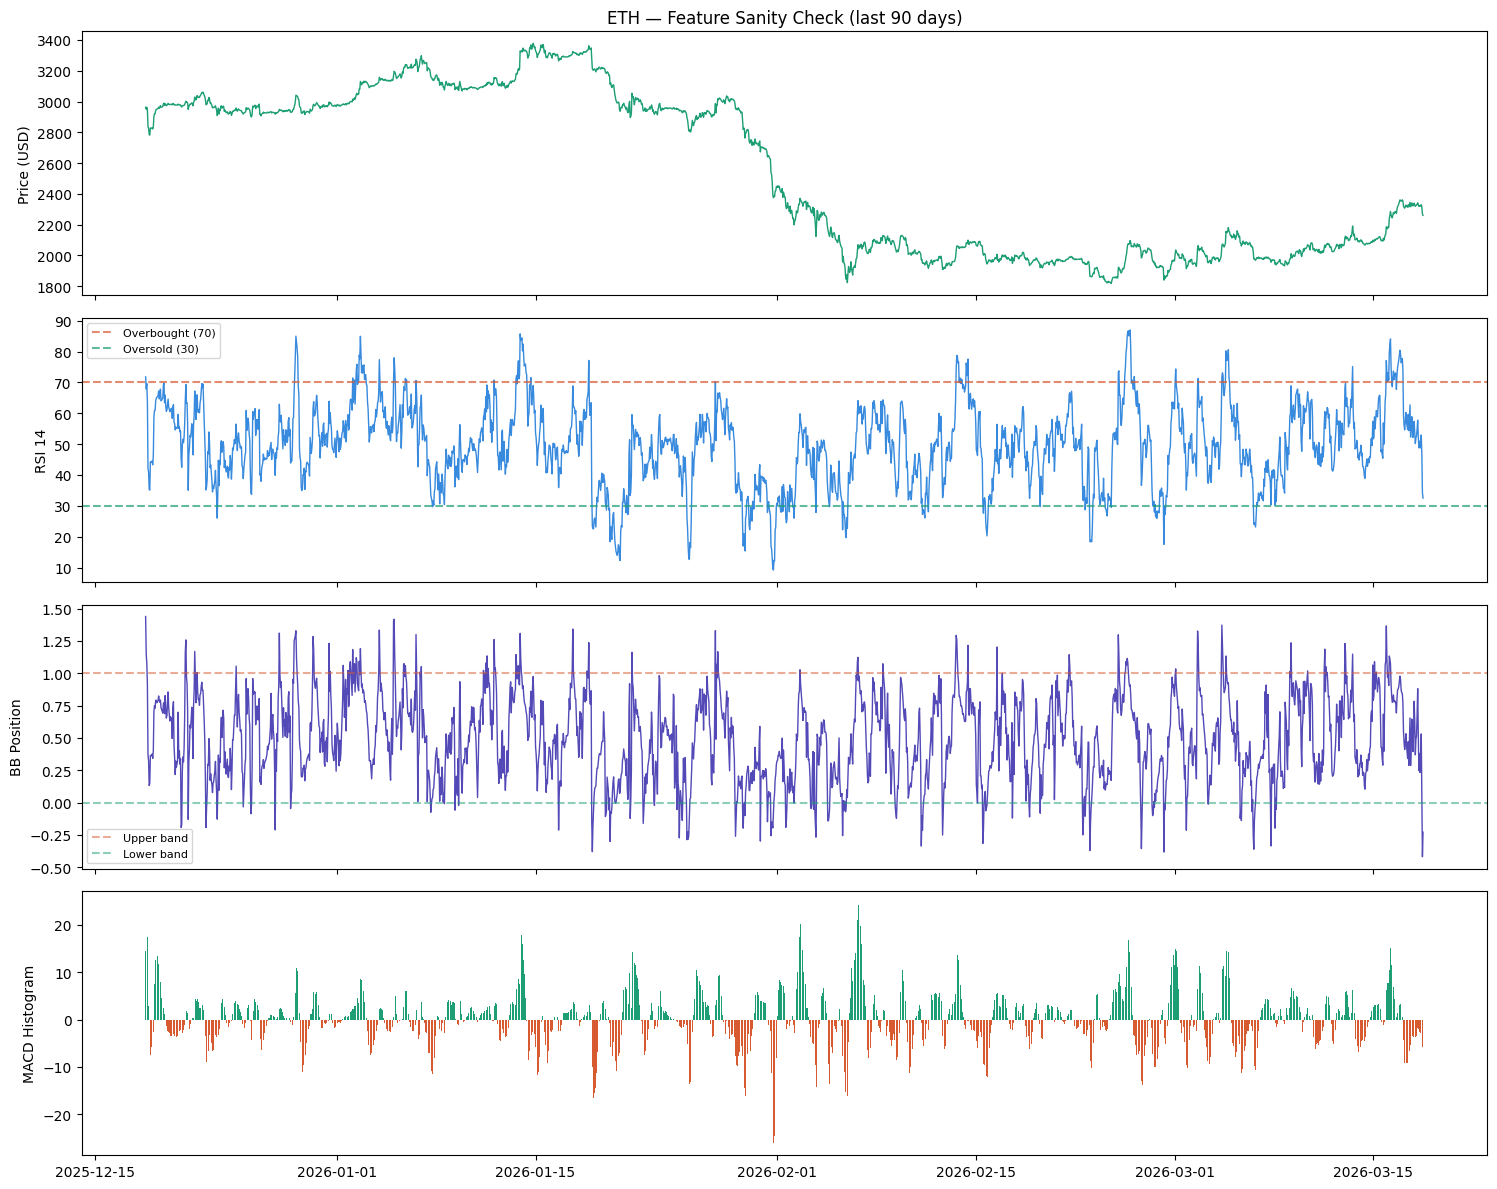

In [74]:
# ETH sanity check chart
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
df_plot_eth = eth_final.last("90D")

axes[0].plot(df_plot_eth.index, df_plot_eth["close"], color="#1D9E75", linewidth=1)
axes[0].set_ylabel("Price (USD)")
axes[0].set_title("ETH — Feature Sanity Check (last 90 days)")

axes[1].plot(df_plot_eth.index, df_plot_eth["rsi_14"], color="#378ADD", linewidth=1)
axes[1].axhline(70, color="#D85A30", linestyle="--", alpha=0.7, label="Overbought (70)")
axes[1].axhline(30, color="#1D9E75", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[1].set_ylabel("RSI 14")
axes[1].legend(fontsize=8)

axes[2].plot(df_plot_eth.index, df_plot_eth["bb_position"], color="#534AB7", linewidth=1)
axes[2].axhline(1.0, color="#D85A30", linestyle="--", alpha=0.5, label="Upper band")
axes[2].axhline(0.0, color="#1D9E75", linestyle="--", alpha=0.5, label="Lower band")
axes[2].set_ylabel("BB Position")
axes[2].legend(fontsize=8)

axes[3].bar(df_plot_eth.index, df_plot_eth["macd_hist"],
            color=["#1D9E75" if v > 0 else "#D85A30" for v in df_plot_eth["macd_hist"]],
            width=0.03)
axes[3].set_ylabel("MACD Histogram")

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "eth_feature_check.png"), dpi=120)
plt.show()